# Báo cáo phân tích benchmark

Notebook này tổng hợp các file `subject_*_benchmark.json` trong thư mục `output/` để:

- so sánh hai chiến lược `tree_based` và `Sequence Chunk Matcher`;
- vẽ biểu đồ về thời gian, chất lượng học và hiệu quả token;
- tạo báo cáo diễn giải chi tiết theo từng môn;
- đào sâu theo từng buổi học cho một môn được chọn.

## Cách đọc nhanh

Ưu tiên diễn giải nên đi theo thứ tự:

1. `prerequisite_ordering_accuracy`: thứ tự tiên quyết có đúng không.
2. `relation_activation_rate`: planner có giữ được cấu trúc quan hệ quan trọng không.
3. `entity_redundancy_ratio`: nội dung chính có bị lặp giữa các buổi không.
4. `tokens_per_unique_entity`: chi phí token để tổ chức mỗi thực thể tri thức là bao nhiêu.

Trong notebook này, `tree_based` thường có lợi thế về tính kỷ luật cấu trúc, còn `Sequence Chunk Matcher` thường có lợi thế về chi phí token và độ phủ relation. Các biểu đồ phía dưới sẽ cho thấy trade-off đó rõ hơn theo từng môn.


In [1]:
from __future__ import annotations

import importlib.util
import json
import subprocess
import sys
from pathlib import Path

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
}
missing_packages = [pkg for module, pkg in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    print('Đang cài các package còn thiếu:', ', '.join(missing_packages))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

In [2]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'output'
BENCHMARK_FILES = sorted(OUTPUT_DIR.glob('subject_*_benchmark.json'))

if not BENCHMARK_FILES:
    raise FileNotFoundError(f'Không tìm thấy file benchmark trong {OUTPUT_DIR}')

def load_report(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as file:
        return json.load(file)

reports = [load_report(path) for path in BENCHMARK_FILES]

def flatten_strategy(report: dict, strategy_key: str) -> dict:
    subject = report['subject']
    strategy = report[strategy_key]
    return {
        'subject_id': subject['subject_id'],
        'subject_name': subject['subject_name'],
        'strategy': strategy_key,
        'ingestion_duration_ms': report['ingestion']['duration_ms'],
        'chunks': report['ingestion']['chunks'],
        'entities_raw': report['ingestion']['entities_raw'],
        'entities_profiled': report['ingestion']['entities_profiled'],
        'relations': report['ingestion']['relations'],
        'fetch_ms': strategy['fetch_ms'],
        'schedule_ms': strategy['schedule_ms'],
        'total_ms': strategy['total_ms'],
        'session_count': strategy['session_count'],
        'total_prompt_tokens': strategy['total_prompt_tokens'],
        'avg_prompt_tokens': strategy['avg_prompt_tokens'],
        'unique_primary_entities': strategy['unique_primary_entities'],
        'total_primary_entity_mentions': strategy['total_primary_entity_mentions'],
        'entity_redundancy_ratio': strategy['entity_redundancy_ratio'],
        'avg_adjacent_entity_overlap': strategy['avg_adjacent_entity_overlap'],
        'prerequisite_total': strategy['prerequisite_total'],
        'prerequisite_evaluable': strategy['prerequisite_evaluable'],
        'prerequisite_correct': strategy['prerequisite_correct'],
        'prerequisite_violations': strategy['prerequisite_violations'],
        'prerequisite_ordering_accuracy': strategy['prerequisite_ordering_accuracy'],
        'key_relation_total': strategy['key_relation_total'],
        'activated_relation_total': strategy['activated_relation_total'],
        'relation_activation_rate': strategy['relation_activation_rate'],
        'prerequisite_activation_rate': strategy['prerequisite_activation_rate'],
        'part_of_activation_rate': strategy['part_of_activation_rate'],
        'tokens_per_unique_entity': strategy['tokens_per_unique_entity'],
    }

summary_df = pd.DataFrame(
    flatten_strategy(report, strategy_key)
    for report in reports
    for strategy_key in ('tree_based', 'vector_db_chunks')
)
summary_df['total_seconds'] = summary_df['total_ms'] / 1000
summary_df['ingestion_minutes'] = summary_df['ingestion_duration_ms'] / 1000 / 60
summary_df['prompt_tokens_k'] = summary_df['total_prompt_tokens'] / 1000

wide_df = summary_df.pivot(index=['subject_id', 'subject_name'], columns='strategy')
wide_df.columns = ['__'.join(column).strip() for column in wide_df.columns.to_flat_index()]
wide_df = wide_df.reset_index()

wide_df['time_delta_seconds'] = wide_df['total_seconds__tree_based'] - wide_df['total_seconds__vector_db_chunks']
wide_df['prereq_delta'] = wide_df['prerequisite_ordering_accuracy__tree_based'] - wide_df['prerequisite_ordering_accuracy__vector_db_chunks']
wide_df['relation_delta'] = wide_df['relation_activation_rate__tree_based'] - wide_df['relation_activation_rate__vector_db_chunks']
wide_df['redundancy_delta'] = wide_df['entity_redundancy_ratio__tree_based'] - wide_df['entity_redundancy_ratio__vector_db_chunks']
wide_df['tokens_per_entity_delta'] = wide_df['tokens_per_unique_entity__tree_based'] - wide_df['tokens_per_unique_entity__vector_db_chunks']

session_rows = []
for report in reports:
    subject = report['subject']
    for strategy_key in ('tree_based', 'vector_db_chunks'):
        for session in report[strategy_key]['sessions']:
            session_rows.append({
                'subject_id': subject['subject_id'],
                'subject_name': subject['subject_name'],
                'strategy': strategy_key,
                'session_index': session['session_index'],
                'weight': session['weight'],
                'primary_entity_count': session['primary_entity_count'],
                'context_entity_count': session['context_entity_count'],
                'activated_relation_count': session['activated_relation_count'],
                'activated_prerequisite_count': session['activated_prerequisite_count'],
                'activated_part_of_count': session['activated_part_of_count'],
                'prompt_tokens': session['prompt_tokens'],
                'aggregate_preview': session['aggregate_preview'],
            })

sessions_df = pd.DataFrame(session_rows)

print(f'Đã tải {len(reports)} file benchmark từ {OUTPUT_DIR}')
summary_df.head()

Đã tải 5 file benchmark từ /home/yootek/projects/yoostudio/smart-learning-assistant/backend/benchmark/output


,subject_id,subject_name,strategy,ingestion_duration_ms,chunks,entities_raw,entities_profiled,relations,fetch_ms,schedule_ms,total_ms,session_count,total_prompt_tokens,avg_prompt_tokens,unique_primary_entities,total_primary_entity_mentions,entity_redundancy_ratio,avg_adjacent_entity_overlap,prerequisite_total,prerequisite_evaluable,prerequisite_correct,prerequisite_violations,prerequisite_ordering_accuracy,key_relation_total,activated_relation_total,relation_activation_rate,prerequisite_activation_rate,part_of_activation_rate,tokens_per_unique_entity,total_seconds,ingestion_minutes,prompt_tokens_k
0,102,Kiểm thử phần mềm,tree_based,1.086271e+06,62,509,438,524,287.415073,177592.684969,177880.100042,10,321660,32166.0,429,429,0.000000,0.000000,128,124,117,7,0.943548,509,495,0.972495,0.968750,0.993151,749.790210,177.880100,18.104509,321.660
1,102,Kiểm thử phần mềm,vector_db_chunks,1.086271e+06,62,509,438,524,46.103046,162490.255255,162536.358301,10,32640,3264.0,438,487,0.100616,0.028141,128,128,114,14,0.890625,509,509,1.000000,1.000000,1.000000,74.520548,162.536358,18.104509,32.640
2,103,Kinh tế vi mô,tree_based,1.652517e+06,46,528,440,536,770.888875,24442.138714,25213.027589,10,337148,33714.8,430,430,0.000000,0.000000,138,133,111,22,0.834586,527,510,0.967742,0.963768,0.990566,784.065116,25.213028,27.541943,337.148
3,103,Kinh tế vi mô,vector_db_chunks,1.652517e+06,46,528,440,536,51.895208,27735.601914,27787.497122,10,28668,2866.8,440,500,0.120000,0.034754,138,138,119,19,0.862319,527,527,1.000000,1.000000,1.000000,65.154545,27.787497,27.541943,28.668
4,104,KTCT Mác Lênin,tree_based,5.318344e+05,57,506,356,503,267.400340,41329.777835,41597.178176,10,280970,28097.0,351,351,0.000000,0.000000,135,134,108,26,0.805970,485,478,0.985567,0.992593,1.000000,800.484330,41.597178,8.863907,280.970


## Bảng tổng hợp nhanh

Bảng dưới đây cho phép nhìn nhanh từng môn theo hai hướng:

- quy mô dữ liệu đầu vào theo môn gồm `chunks`, `entities_profiled` và `relations`;
- `total_seconds`: thời gian lập kế hoạch thực tế;
- `prerequisite_ordering_accuracy` và `relation_activation_rate`: chất lượng cấu trúc học;
- `entity_redundancy_ratio`: mức lặp lại nội dung chính;
- `tokens_per_unique_entity`: chi phí token để tổ chức tri thức.

Trong notebook này, `entities_profiled` được dùng như số entity cuối cùng sau bước profiling. Nếu một chiến lược nhanh hơn nhưng trả giá bằng `prerequisite_ordering_accuracy` thấp hơn, đó là trade-off chất lượng chứ không phải thắng tuyệt đối.


In [3]:
subject_size_df = (
    summary_df[["subject_id", "subject_name", "chunks", "entities_profiled", "relations"]]
    .drop_duplicates()
    .sort_values("subject_id")
    .rename(columns={"entities_profiled": "entities"})
)

subject_size_df

,subject_id,subject_name,chunks,entities,relations
0,102,Kiểm thử phần mềm,62,438,524
2,103,Kinh tế vi mô,46,440,536
4,104,KTCT Mác Lênin,57,356,503
6,105,Logic học đại cương,64,510,534
8,106,Tâm lý học sức khoẻ,64,839,706


In [4]:
display_columns = [
    'subject_id',
    'subject_name',
    'strategy',
    'chunks',
    'entities_profiled',
    'relations',
    'total_seconds',
    'prerequisite_ordering_accuracy',
    'relation_activation_rate',
    'entity_redundancy_ratio',
    'tokens_per_unique_entity',
    'total_prompt_tokens',
]
summary_df[display_columns].sort_values(['subject_id', 'strategy']).round({
    'total_seconds': 2,
    'prerequisite_ordering_accuracy': 3,
    'relation_activation_rate': 3,
    'entity_redundancy_ratio': 3,
    'tokens_per_unique_entity': 1,
})

,subject_id,subject_name,strategy,chunks,entities_profiled,relations,total_seconds,prerequisite_ordering_accuracy,relation_activation_rate,entity_redundancy_ratio,tokens_per_unique_entity,total_prompt_tokens
0,102,Kiểm thử phần mềm,tree_based,62,438,524,177.88,0.944,0.972,0.000,749.8,321660
1,102,Kiểm thử phần mềm,vector_db_chunks,62,438,524,162.54,0.891,1.000,0.101,74.5,32640
2,103,Kinh tế vi mô,tree_based,46,440,536,25.21,0.835,0.968,0.000,784.1,337148
3,103,Kinh tế vi mô,vector_db_chunks,46,440,536,27.79,0.862,1.000,0.120,65.2,28668
4,104,KTCT Mác Lênin,tree_based,57,356,503,41.60,0.806,0.986,0.000,800.5,280970
5,104,KTCT Mác Lênin,vector_db_chunks,57,356,503,25.55,0.785,1.000,0.207,88.6,31556
6,105,Logic học đại cương,tree_based,64,510,534,39.67,0.977,0.973,0.000,768.3,384134
7,105,Logic học đại cương,vector_db_chunks,64,510,534,32.51,0.933,1.000,0.040,95.4,48658
8,106,Tâm lý học sức khoẻ,tree_based,64,839,706,74.44,0.989,0.997,0.000,824.3,689920
9,106,Tâm lý học sức khoẻ,vector_db_chunks,64,839,706,41.66,0.947,1.000,0.078,46.2,38776


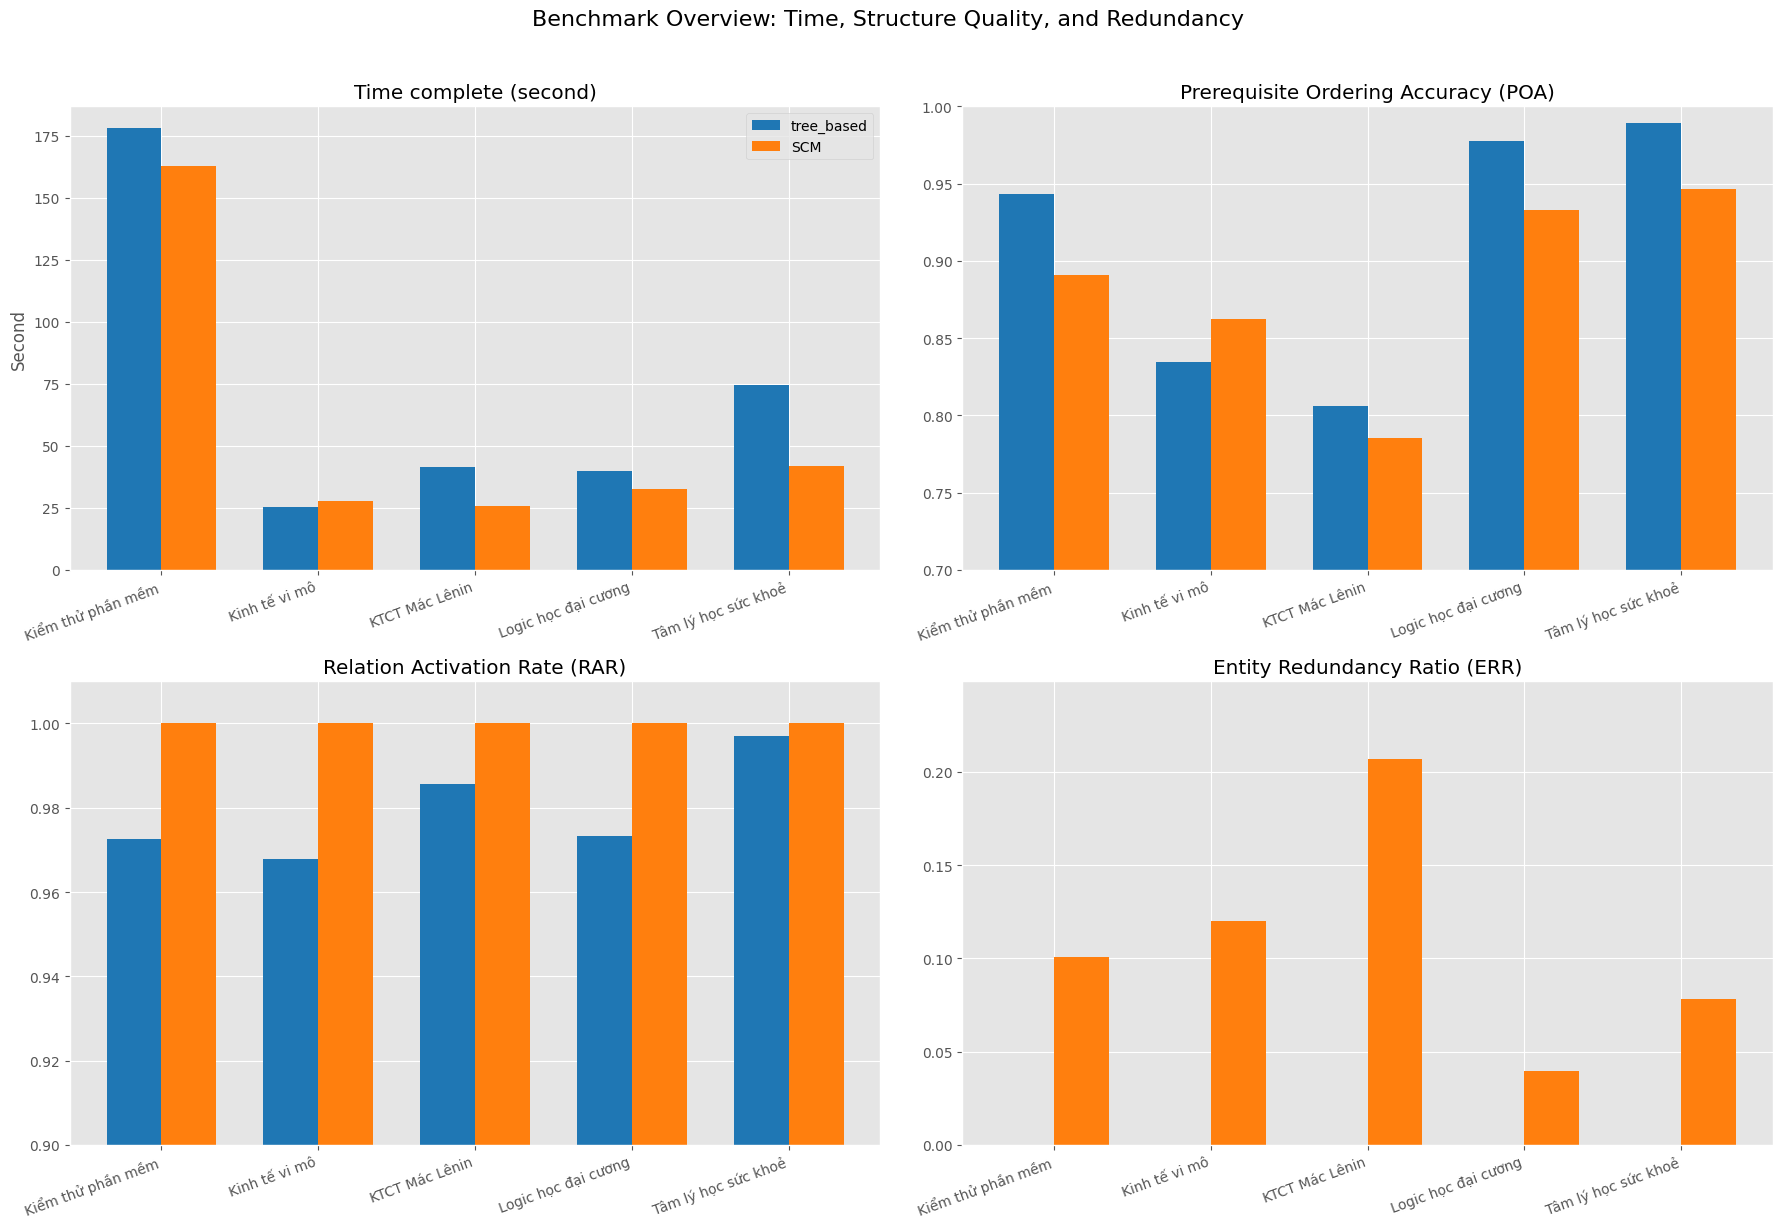

In [9]:
subjects = summary_df['subject_name'].drop_duplicates().tolist()
x = np.arange(len(subjects))
bar_width = 0.35
tree_df = summary_df[summary_df['strategy'] == 'tree_based'].sort_values('subject_id').reset_index(drop=True)
vector_df = summary_df[summary_df['strategy'] == 'vector_db_chunks'].sort_values('subject_id').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].bar(x - bar_width / 2, tree_df['total_seconds'], width=bar_width, label='tree_based', color='#1f77b4')
axes[0, 0].bar(x + bar_width / 2, vector_df['total_seconds'], width=bar_width, label='SCM', color='#ff7f0e')
axes[0, 0].set_title('Time complete (second)')
axes[0, 0].set_xticks(x, subjects, rotation=20, ha='right')
axes[0, 0].set_ylabel('Second')
axes[0, 0].legend()

axes[0, 1].bar(x - bar_width / 2, tree_df['prerequisite_ordering_accuracy'], width=bar_width, label='tree_based', color='#1f77b4')
axes[0, 1].bar(x + bar_width / 2, vector_df['prerequisite_ordering_accuracy'], width=bar_width, label='Sequence Chunk Matcher', color='#ff7f0e')
axes[0, 1].set_title('Prerequisite Ordering Accuracy (POA)')
axes[0, 1].set_xticks(x, subjects, rotation=20, ha='right')
axes[0, 1].set_ylim(0.7, 1.0)

axes[1, 0].bar(x - bar_width / 2, tree_df['relation_activation_rate'], width=bar_width, label='tree_based', color='#1f77b4')
axes[1, 0].bar(x + bar_width / 2, vector_df['relation_activation_rate'], width=bar_width, label='Sequence Chunk Matcher', color='#ff7f0e')
axes[1, 0].set_title('Relation Activation Rate (RAR)')
axes[1, 0].set_xticks(x, subjects, rotation=20, ha='right')
axes[1, 0].set_ylim(0.9, 1.01)

axes[1, 1].bar(x - bar_width / 2, tree_df['entity_redundancy_ratio'], width=bar_width, label='tree_based', color='#1f77b4')
axes[1, 1].bar(x + bar_width / 2, vector_df['entity_redundancy_ratio'], width=bar_width, label='Sequence Chunk Matcher', color='#ff7f0e')
axes[1, 1].set_title('Entity Redundancy Ratio (ERR)')
axes[1, 1].set_xticks(x, subjects, rotation=20, ha='right')
axes[1, 1].set_ylim(0, max(summary_df['entity_redundancy_ratio'].max() * 1.2, 0.1))

fig.suptitle('Benchmark Overview: Time, Structure Quality, and Redundancy', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


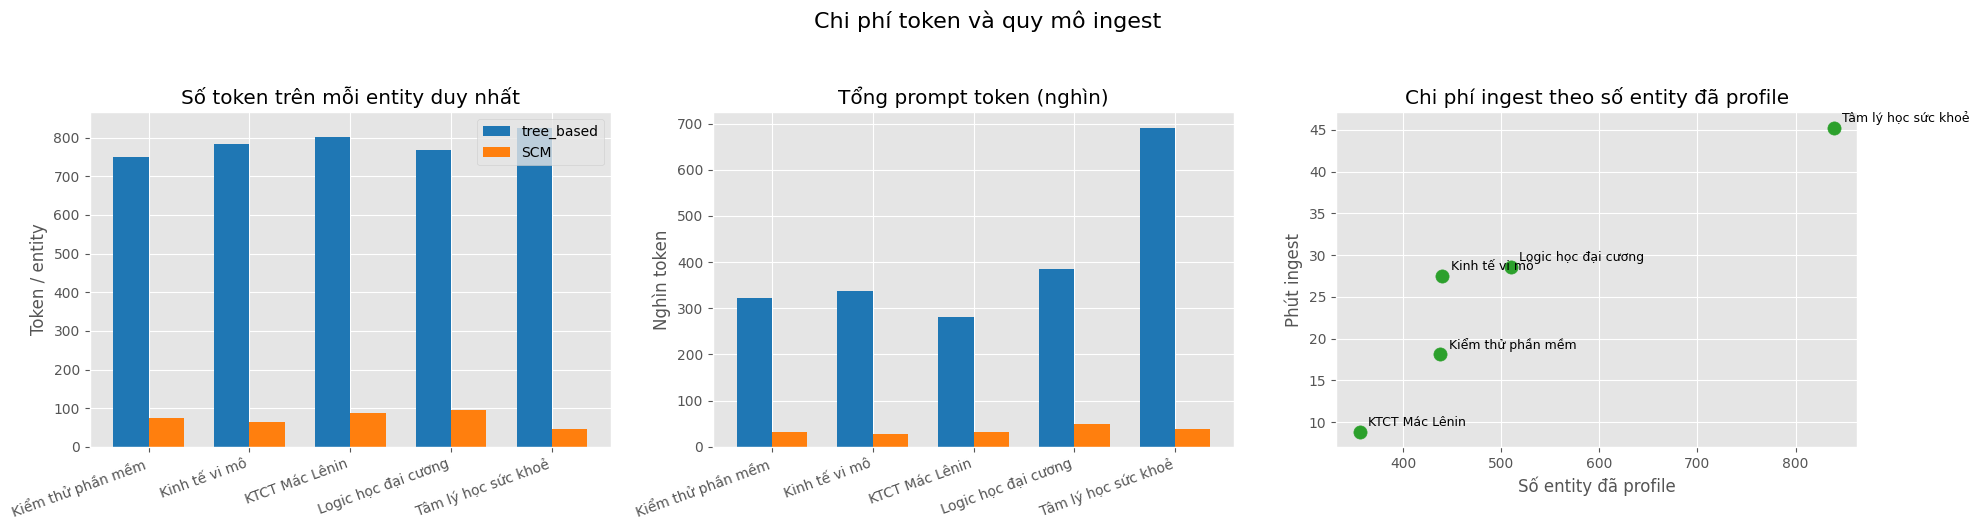

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].bar(x - bar_width / 2, tree_df['tokens_per_unique_entity'], width=bar_width, label='tree_based', color='#1f77b4')
axes[0].bar(x + bar_width / 2, vector_df['tokens_per_unique_entity'], width=bar_width, label='SCM', color='#ff7f0e')
axes[0].set_title('Số token trên mỗi entity duy nhất')
axes[0].set_xticks(x, subjects, rotation=20, ha='right')
axes[0].set_ylabel('Token / entity')
axes[0].legend()

axes[1].bar(x - bar_width / 2, tree_df['prompt_tokens_k'], width=bar_width, label='tree_based', color='#1f77b4')
axes[1].bar(x + bar_width / 2, vector_df['prompt_tokens_k'], width=bar_width, label='Sequence Chunk Matcher', color='#ff7f0e')
axes[1].set_title('Tổng prompt token (nghìn)')
axes[1].set_xticks(x, subjects, rotation=20, ha='right')
axes[1].set_ylabel('Nghìn token')

scatter_df = summary_df.drop_duplicates('subject_id').sort_values('subject_id')
axes[2].scatter(scatter_df['entities_profiled'], scatter_df['ingestion_minutes'], color='#2ca02c', s=90)
for _, row in scatter_df.iterrows():
    axes[2].annotate(row['subject_name'], (row['entities_profiled'], row['ingestion_minutes']), xytext=(6, 4), textcoords='offset points', fontsize=9)
axes[2].set_title('Chi phí ingest theo số entity đã profile')
axes[2].set_xlabel('Số entity đã profile')
axes[2].set_ylabel('Phút ingest')

fig.suptitle('Chi phí token và quy mô ingest', fontsize=16, y=1.05)
fig.tight_layout()
plt.show()


In [7]:
aggregate_df = summary_df.groupby('strategy').agg({
    'total_seconds': 'mean',
    'prerequisite_ordering_accuracy': 'mean',
    'relation_activation_rate': 'mean',
    'entity_redundancy_ratio': 'mean',
    'tokens_per_unique_entity': 'mean',
    'total_prompt_tokens': 'mean',
}).round(3)

win_counts = {
    'faster_runtime': int((wide_df['time_delta_seconds'] > 0).sum()),
    'better_prereq': int((wide_df['prereq_delta'] > 0).sum()),
    'better_relation_activation': int((wide_df['relation_delta'] > 0).sum()),
    'lower_redundancy': int((wide_df['redundancy_delta'] < 0).sum()),
    'better_token_efficiency': int((wide_df['tokens_per_entity_delta'] > 0).sum()),
}

fastest_subject = wide_df.loc[wide_df['time_delta_seconds'].idxmax()]
strongest_tree_subject = wide_df.loc[wide_df['prereq_delta'].idxmax()]
strongest_vector_subject = wide_df.loc[wide_df['prereq_delta'].idxmin()]
heaviest_ingestion_subject = scatter_df.loc[scatter_df['ingestion_minutes'].idxmax()]
largest_entity_subject = subject_size_df.loc[subject_size_df['entities'].idxmax()]
largest_relation_subject = subject_size_df.loc[subject_size_df['relations'].idxmax()]
largest_chunk_subject = subject_size_df.loc[subject_size_df['chunks'].idxmax()]

report_lines = [
    '# Báo cáo tổng hợp tự động',
    '',
    '## Tổng quan chiến lược',
    f"- Tree-based thắng {win_counts['better_prereq']}/{len(wide_df)} môn về thứ tự prerequisite.",
    f"- Sequence Chunk Matcher thắng {win_counts['faster_runtime']}/{len(wide_df)} môn về tốc độ runtime.",
    f"- Sequence Chunk Matcher đạt relation activation vượt hoặc bằng tree-based ở {len(wide_df) - win_counts['better_relation_activation']}/{len(wide_df)} môn.",
    f"- Tree-based có redundancy thấp hơn ở {win_counts['lower_redundancy']}/{len(wide_df)} môn.",
    f"- Sequence Chunk Matcher hiệu quả token tốt hơn ở {win_counts['better_token_efficiency']}/{len(wide_df)} môn.",
    '',
    '## Quy mô dữ liệu theo môn',
    f"- Môn có nhiều entities nhất là **{largest_entity_subject['subject_name']}** với {int(largest_entity_subject['entities'])} entities.",
    f"- Môn có nhiều relations nhất là **{largest_relation_subject['subject_name']}** với {int(largest_relation_subject['relations'])} relations.",
    f"- Môn có nhiều chunks nhất là **{largest_chunk_subject['subject_name']}** với {int(largest_chunk_subject['chunks'])} chunks.",
    '',
    '## Trung bình toàn bộ dataset',
    aggregate_df.to_markdown(),
    '',
    '## Nhận định chi tiết',
    f"- Môn chênh lệch runtime nghiêng về Sequence Chunk Matcher rõ nhất là **{fastest_subject['subject_name']}**, tree-based chậm hơn khoảng {fastest_subject['time_delta_seconds']:.2f} giây.",
    f"- Môn tree-based vượt Sequence Chunk Matcher rõ nhất về prerequisite là **{strongest_tree_subject['subject_name']}** với delta {strongest_tree_subject['prereq_delta']:.3f}.",
    f"- Môn Sequence Chunk Matcher vượt tree rõ nhất về prerequisite là **{strongest_vector_subject['subject_name']}** với delta {abs(strongest_vector_subject['prereq_delta']):.3f} theo hướng Sequence Chunk Matcher tốt hơn.",
    f"- Môn ingest nặng nhất hiện tại là **{heaviest_ingestion_subject['subject_name']}** với khoảng {heaviest_ingestion_subject['ingestion_minutes']:.1f} phút và {int(heaviest_ingestion_subject['entities_profiled'])} profiled entities.",
    '',
    '## Cách diễn giải thực tế',
    '- Nếu ưu tiên chất lượng pedagogical structure, cần xem prerequisite accuracy và redundancy trước khi xem tốc độ.',
    '- Nếu ưu tiên chi phí prompt và throughput, Sequence Chunk Matcher đang có lợi thế rất rõ ràng.',
    '- Nếu cần một planner cân bằng, cần xem các môn mà Sequence Chunk Matcher nhanh hơn nhưng prerequisite accuracy không giảm hoặc tăng.',
]

display(Markdown('\n'.join(report_lines)))


# Báo cáo tổng hợp tự động

## Tổng quan chiến lược
- Tree-based thắng 4/5 môn về thứ tự prerequisite.
- Sequence Chunk Matcher thắng 4/5 môn về tốc độ runtime.
- Sequence Chunk Matcher đạt relation activation vượt hoặc bằng tree-based ở 5/5 môn.
- Tree-based có redundancy thấp hơn ở 5/5 môn.
- Sequence Chunk Matcher hiệu quả token tốt hơn ở 5/5 môn.

## Quy mô dữ liệu theo môn
- Môn có nhiều entities nhất là **Tâm lý học sức khoẻ** với 839 entities.
- Môn có nhiều relations nhất là **Tâm lý học sức khoẻ** với 706 relations.
- Môn có nhiều chunks nhất là **Logic học đại cương** với 64 chunks.

## Trung bình toàn bộ dataset
| strategy         |   total_seconds |   prerequisite_ordering_accuracy |   relation_activation_rate |   entity_redundancy_ratio |   tokens_per_unique_entity |   total_prompt_tokens |
|:-----------------|----------------:|---------------------------------:|---------------------------:|--------------------------:|---------------------------:|----------------------:|
| tree_based       |          71.759 |                            0.91  |                      0.979 |                     0     |                    785.377 |              402766   |
| vector_db_chunks |          58.007 |                            0.883 |                      1     |                     0.109 |                     73.988 |               36059.6 |

## Nhận định chi tiết
- Môn chênh lệch runtime nghiêng về Sequence Chunk Matcher rõ nhất là **Tâm lý học sức khoẻ**, tree-based chậm hơn khoảng 32.78 giây.
- Môn tree-based vượt Sequence Chunk Matcher rõ nhất về prerequisite là **Kiểm thử phần mềm** với delta 0.053.
- Môn Sequence Chunk Matcher vượt tree rõ nhất về prerequisite là **Kinh tế vi mô** với delta 0.028 theo hướng Sequence Chunk Matcher tốt hơn.
- Môn ingest nặng nhất hiện tại là **Tâm lý học sức khoẻ** với khoảng 45.3 phút và 839 profiled entities.

## Cách diễn giải thực tế
- Nếu ưu tiên chất lượng pedagogical structure, cần xem prerequisite accuracy và redundancy trước khi xem tốc độ.
- Nếu ưu tiên chi phí prompt và throughput, Sequence Chunk Matcher đang có lợi thế rất rõ ràng.
- Nếu cần một planner cân bằng, cần xem các môn mà Sequence Chunk Matcher nhanh hơn nhưng prerequisite accuracy không giảm hoặc tăng.

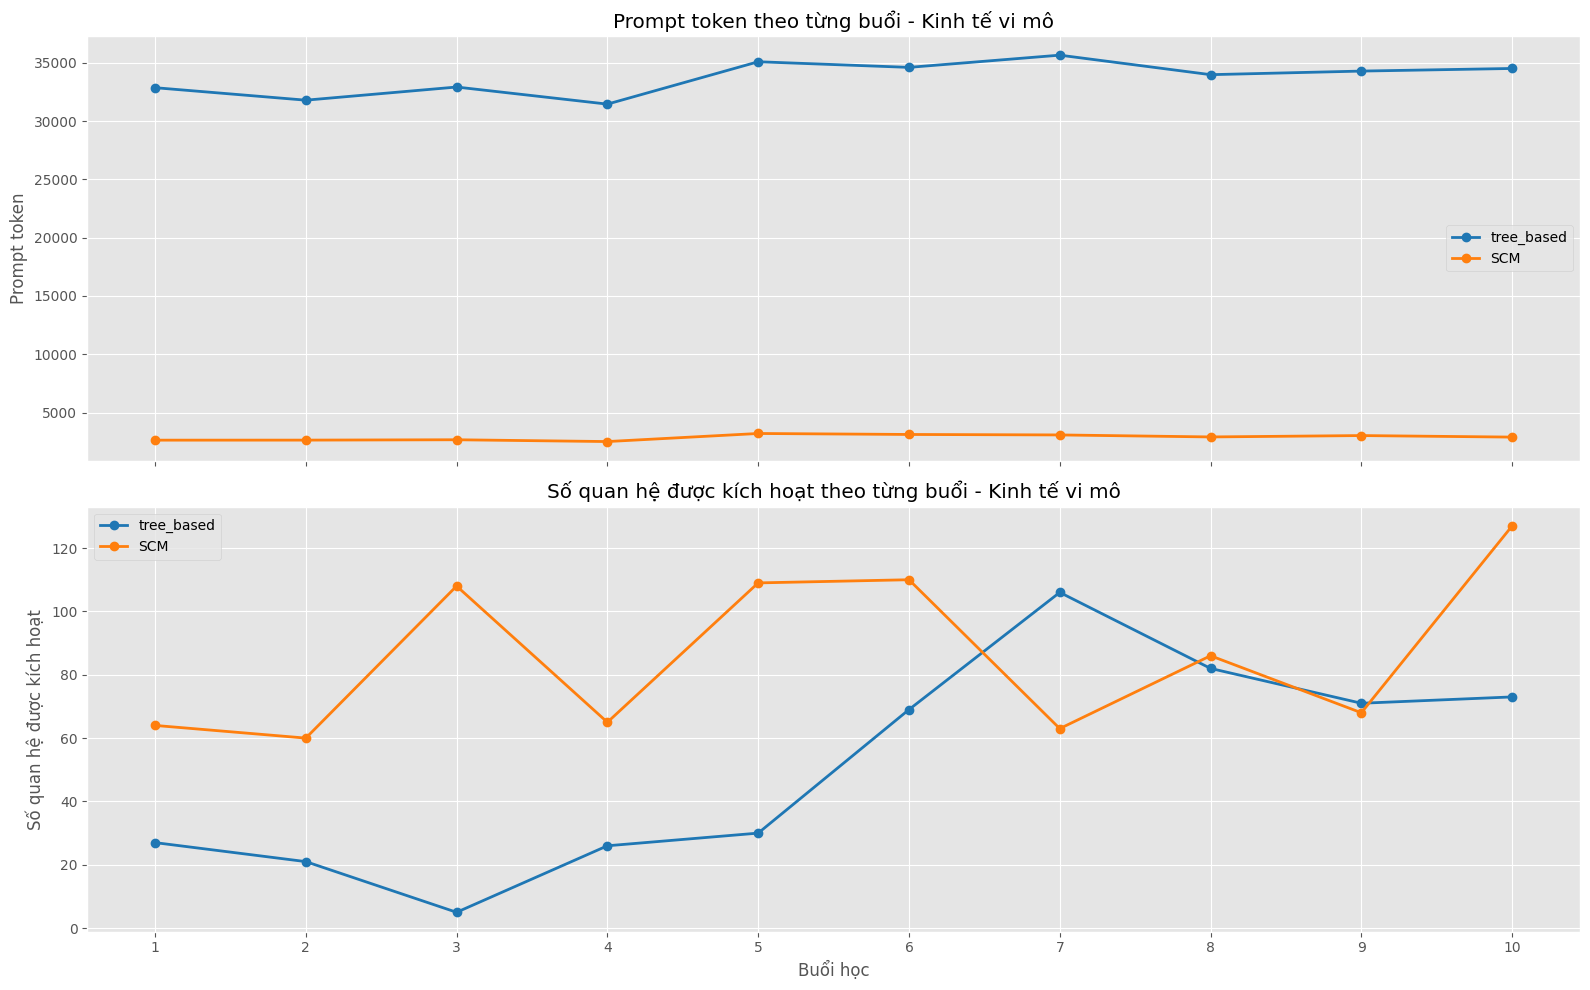

# Phân tích sâu: Kinh tế vi mô

- Tree-based runtime: **25.21s**; Sequence Chunk Matcher runtime: **27.79s**.
- Tree-based prerequisite accuracy: **0.835**; Sequence Chunk Matcher: **0.862**.
- Tree-based relation activation: **0.968**; Sequence Chunk Matcher: **1.000**.
- Tree-based redundancy: **0.000**; Sequence Chunk Matcher: **0.120**.
- Tree-based token trên mỗi entity: **784.1**; Sequence Chunk Matcher: **65.2**.

## Diễn giải
- Nếu nhìn theo từng buổi, tree-based duy trì prompt token rất cao và khá đều qua các session, cho thấy planner đang mang nhiều cấu trúc và context vào mỗi lần sinh nội dung.
- Sequence Chunk Matcher kích hoạt relation mạnh hơn trong nhiều buổi với chi phí token thấp hơn rất nhiều, nên phù hợp cho trường hợp ưu tiên throughput.
- Trường hợp môn này là một ví dụ quan trọng: Sequence Chunk Matcher nhanh hơn và prerequisite accuracy cũng nhỉnh hơn tree-based, nghĩa là tree-based không phải lúc nào cũng là lựa chọn tốt nhất.

,strategy,session_index,primary_entity_count,context_entity_count,activated_relation_count,prompt_tokens,aggregate_preview
20,tree_based,1,43,1,27,32863,Nội dung buổi học hôm nay bao gồm:\n- Phép tư ...
21,tree_based,2,43,1,21,31791,Nội dung buổi học hôm nay bao gồm:\n- tâm lý h...
22,tree_based,3,43,1,5,32919,Nội dung buổi học hôm nay bao gồm:\n- Trung gi...
23,tree_based,4,43,1,26,31453,Nội dung buổi học hôm nay bao gồm:\n- Giá cả c...
24,tree_based,5,43,1,30,35087,Nội dung buổi học hôm nay bao gồm:\n- P (price...
25,tree_based,6,43,26,69,34605,Nội dung buổi học hôm nay bao gồm:\n- Hình 2.1...


In [12]:
subject_reports = {report['subject']['subject_id']: report for report in reports}
FOCUS_SUBJECT_ID = 103
focus_report = subject_reports[FOCUS_SUBJECT_ID]
focus_subject_name = focus_report['subject']['subject_name']
focus_sessions = sessions_df[sessions_df['subject_id'] == FOCUS_SUBJECT_ID].sort_values(['strategy', 'session_index'])
focus_tree = focus_sessions[focus_sessions['strategy'] == 'tree_based'].sort_values('session_index')
focus_vector = focus_sessions[focus_sessions['strategy'] == 'vector_db_chunks'].sort_values('session_index')

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
session_x = focus_tree['session_index'].to_numpy()

axes[0].plot(session_x, focus_tree['prompt_tokens'], marker='o', linewidth=2, label='tree_based', color='#1f77b4')
axes[0].plot(session_x, focus_vector['prompt_tokens'], marker='o', linewidth=2, label='SCM', color='#ff7f0e')
axes[0].set_title(f'Prompt token theo từng buổi - {focus_subject_name}')
axes[0].set_ylabel('Prompt token')
axes[0].legend()

axes[1].plot(session_x, focus_tree['activated_relation_count'], marker='o', linewidth=2, label='tree_based', color='#1f77b4')
axes[1].plot(session_x, focus_vector['activated_relation_count'], marker='o', linewidth=2, label='SCM', color='#ff7f0e')
axes[1].set_title(f'Số quan hệ được kích hoạt theo từng buổi - {focus_subject_name}')
axes[1].set_ylabel('Số quan hệ được kích hoạt')
axes[1].set_xlabel('Buổi học')
axes[1].set_xticks(session_x)
axes[1].legend()

fig.tight_layout()
plt.show()

focus_summary = wide_df[wide_df['subject_id'] == FOCUS_SUBJECT_ID].iloc[0]
deep_dive_lines = [
    f'# Phân tích sâu: {focus_subject_name}',
    '',
    f"- Tree-based runtime: **{focus_summary['total_seconds__tree_based']:.2f}s**; Sequence Chunk Matcher runtime: **{focus_summary['total_seconds__vector_db_chunks']:.2f}s**.",
    f"- Tree-based prerequisite accuracy: **{focus_summary['prerequisite_ordering_accuracy__tree_based']:.3f}**; Sequence Chunk Matcher: **{focus_summary['prerequisite_ordering_accuracy__vector_db_chunks']:.3f}**.",
    f"- Tree-based relation activation: **{focus_summary['relation_activation_rate__tree_based']:.3f}**; Sequence Chunk Matcher: **{focus_summary['relation_activation_rate__vector_db_chunks']:.3f}**.",
    f"- Tree-based redundancy: **{focus_summary['entity_redundancy_ratio__tree_based']:.3f}**; Sequence Chunk Matcher: **{focus_summary['entity_redundancy_ratio__vector_db_chunks']:.3f}**.",
    f"- Tree-based token trên mỗi entity: **{focus_summary['tokens_per_unique_entity__tree_based']:.1f}**; Sequence Chunk Matcher: **{focus_summary['tokens_per_unique_entity__vector_db_chunks']:.1f}**.",
    '',
    '## Diễn giải',
    '- Nếu nhìn theo từng buổi, tree-based duy trì prompt token rất cao và khá đều qua các session, cho thấy planner đang mang nhiều cấu trúc và context vào mỗi lần sinh nội dung.',
    '- Sequence Chunk Matcher kích hoạt relation mạnh hơn trong nhiều buổi với chi phí token thấp hơn rất nhiều, nên phù hợp cho trường hợp ưu tiên throughput.',
    '- Trường hợp môn này là một ví dụ quan trọng: Sequence Chunk Matcher nhanh hơn và prerequisite accuracy cũng nhỉnh hơn tree-based, nghĩa là tree-based không phải lúc nào cũng là lựa chọn tốt nhất.',
]
display(Markdown('\n'.join(deep_dive_lines)))

preview_table = focus_sessions[['strategy', 'session_index', 'primary_entity_count', 'context_entity_count', 'activated_relation_count', 'prompt_tokens', 'aggregate_preview']]
preview_table.head(6)
